In [1]:
import numpy as np
from itertools import permutations
from qpe import *

from time import time

from scipy.stats import unitary_group, gaussian_kde

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

matplotlib.rcParams['font.family']='serif'
matplotlib.rcParams['axes.unicode_minus']=False
matplotlib.rcParams.update({'font.size': 20})
matplotlib.rc('text', usetex=False)
import random
matplotlib.rc('text', usetex=True)
import math
from itertools import permutations
import itertools

In [2]:
from tenfuncs import *

In [3]:
n_inp = 2
n_copies = 4
n_tot = n_inp*n_copies
n_test = 1000
mixed = True
marks = "negSq"
eps = 1e-3
# dms_test, labels_test = gen_even_ent_data(n_test, n_inp=n_inp, mixed=mixed, marks=marks, eps=eps)
# np.savez("qubitsMixedNegSq1000states.npz", dms_test=dms_test, labels_test=labels_test)
data = np.load("qubitsMixedNegSq1000states.npz")
dms_test=data['dms_test']
labels_test=data['labels_test']

In [4]:
n_train=1000
# dms_train, labels_train = gen_even_ent_data(n_train, n_inp=n_inp, mixed=mixed, marks=marks, eps=eps)
# np.savez("qubitsMixedNegSq1000states_train.npz", dms_train=dms_train, labels_train=labels_train)
data = np.load("qubitsMixedNegSq1000states_train.npz")
dms_train=data['dms_train']
labels_train=data['labels_train']

In [5]:
# n_data=12*50
# n_data=12*5
# n_data=12*20
n_data=500
dms_train_easy, labels_train_easy=get_data_train(points=n_data, both=True)
dms_train_easy_np=[dm.toarray() for dm in dms_train_easy]

In [6]:
dms_train_easy_1000, labels_train_easy_1000=get_data_train(points=1000, both=True)
dms_train_easy_np1000=[dm.toarray() for dm in dms_train_easy_1000]

In [7]:
def fn_rho1(dm):
    return np.trace(dm@dm).real**2
def fn_rho2(dm):
    return np.trace(dm@dm).real
def reshuffle(rho, dA, dB):
    # rho shape: (dA*dB, dA*dB)
    # reshape to (dA, dB, dA, dB), permute to (dA, dA, dB, dB), then flatten
    R = rho.reshape(dA, dB, dA, dB).transpose(0,2,1,3).reshape(dA*dA, dB*dB)
    return R

def compute_E(rho, dA=2, dB=2):
    R = reshuffle(rho, dA, dB)
    M = R @ R.conj().T   # M = R R^\dagger, Hermitian
    E = np.trace(M @ M).real   # should be real and >=0
    return E
def fn_rho3(dm):
    # lmbda_s=get_schmidt_coefficients(dm)
    # return sum(lmbda_s**2)
    return compute_E(dm, 2, 2)

def fn_rho4_a(dm):
    dm_a=partial_trace(dm, subsystem=1)
    return np.trace(dm_a@dm_a).real*np.trace(dm@dm).real
def fn_rho4_b(dm):
    dm_b=partial_trace(dm, subsystem=0)
    return np.trace(dm_b@dm_b).real*np.trace(dm@dm).real

def fn_rho4_ab(dm):
    dm_a=partial_trace(dm, subsystem=1)
    dm_b=partial_trace(dm, subsystem=0)
    
    return np.trace(dm_a@dm_a).real*np.trace(dm@dm).real+np.trace(dm_b@dm_b).real*np.trace(dm@dm).real


def fn_rho5_a(dm):
    dm_a=partial_trace(dm, subsystem=1)
    dm_new=partial_trace(np.kron(dm_a, np.eye(2))@dm, subsystem=0)
    return np.trace(dm_new@dm_new).real
    
def fn_rho5_b(dm):
    dm_b=partial_trace(dm, subsystem=0)
    dm_new=partial_trace(dm@np.kron(np.eye(2), dm_b), subsystem=1)
    return np.trace(dm_new@dm_new).real

def fn_rho5_ab(dm):
    dm_a=partial_trace(dm, subsystem=1)
    dm_new_a=partial_trace(np.kron(dm_a, np.eye(2))@dm, subsystem=0)
    dm_b=partial_trace(dm, subsystem=0)
    dm_new_b=partial_trace(dm@np.kron(np.eye(2), dm_b), subsystem=1)
    return np.trace(dm_new_a@dm_new_a).real+np.trace(dm_new_b@dm_new_b).real

def fn_rho6_a(dm):
    dm_a=partial_trace(dm, subsystem=1)
    return np.trace(dm_a@dm_a).real
def fn_rho6_b(dm):
    dm_b=partial_trace(dm, subsystem=0)
    return np.trace(dm_b@dm_b).real
    
def fn_rho6_ab(dm):
    dm_a=partial_trace(dm, subsystem=1)
    dm_b=partial_trace(dm, subsystem=0)
    return np.trace(dm_a@dm_a).real+np.trace(dm_b@dm_b).real

def fn_rho7(dm):
    dm_a=partial_trace(dm, subsystem=1)
    dm_b=partial_trace(dm, subsystem=0)
    return np.trace(dm@np.kron(dm_a, dm_b)).real
    
def fn_rho8(dm):
    dm_a=partial_trace(dm, subsystem=1)
    dm_b=partial_trace(dm, subsystem=0)
    return np.trace(dm_a@dm_a).real*np.trace(dm_b@dm_b).real

def fn_rho9_a(dm):
    dm_a=partial_trace(dm, subsystem=1)
    return (np.trace(dm_a@dm_a).real)**2
def fn_rho9_b(dm):
    dm_b=partial_trace(dm, subsystem=0)
    return (np.trace(dm_b@dm_b).real)**2
def fn_rho9_ab(dm):
    dm_a=partial_trace(dm, subsystem=1)
    dm_b=partial_trace(dm, subsystem=0)
    return (np.trace(dm_a@dm_a).real)**2+(np.trace(dm_b@dm_b).real)**2

def fn_rho10(dm):
    return 1

In [8]:
def plot_prediction_func_tt(pars, func, dms, labels,func_args=(), results_only=False, save_plot=None, titleMSEVar=False):
    dms_train, dms_test = dms
    labels_train, labels_test = labels

    
    preds_train = [func(pars, dm, *func_args) for dm in dms_train]
    preds_test = [func(pars, dm, *func_args) for dm in dms_test]
    
    total_mse_train = sum([(e1 - e2)**2 for e1, e2 in zip(preds_train, labels_train)]) / len(labels_train)
    total_mse_test = sum([(e1 - e2)**2 for e1, e2 in zip(preds_test, labels_test)]) / len(labels_test)
    
    if results_only:
        return total_mse_train, total_mse_test
    
    purities_test = [trace(dm @ dm).real for dm in dms_test]
    
    # Create colormaps (truncated to 0.25-1.0 range)
    cmap1 = plt.get_cmap("Purples")
    colors1 = cmap1(np.linspace(0.25, 1., 256))
    cmap1 = LinearSegmentedColormap.from_list("truncated_Purples", colors1)
    
    # Create figure and axis
    plt.figure(figsize=(10, 6))
    plt.rcParams['axes.axisbelow'] = True
    
    # Plot test data first (background)
    sc_test = plt.scatter(
        labels_test, preds_test, 
        c=purities_test, cmap=cmap1, s=35, 
        edgecolor='none', label="test", vmin=0.25, vmax=1.0,
        alpha=0.6  # Make test points slightly transparent
    )
    
    # Plot train data LAST so it's on top - make it more visible
    sc_train = plt.scatter(
        labels_train, preds_train, 
        color="red", edgecolor='none', label="train", 
        s=6,  # Increased size
        alpha=0.8,  # Slightly transparent but still vivid
        marker='s',  # Use square markers for better visibility
        zorder=10  # Ensure train points are on top
    )
    
    print(f"MSE_train=%.8f, MSE_test=%.8f" % (total_mse_train, total_mse_test))
    plt.plot(labels_test, labels_test, color="black", lw=1, zorder=5)

    if titleMSEVar:
        plt.title(f"MSE_train=%.8f, MSE_test=%.8f" % (total_mse_train, total_mse_test))
    
    plt.xlabel(r"$N^2$")
    plt.ylabel(r"$\mathsf{N}^2$")
    plt.grid()
    leg = plt.legend(fontsize=20)
    for handle in leg.legend_handles:
        handle.set_sizes([70])
    
    # Add colorbar only for the test data scatter plot
    cbar = plt.colorbar(sc_test)
    #cbar.set_label('Purity')
    
    if save_plot is not None:
        plt.savefig(save_plot, bbox_inches='tight')
    plt.show()

In [10]:
from sklearn.linear_model import LinearRegression
def train_func(fn_s, dms, labels, fit_intercept=False):
    X_train=np.zeros((len(labels),len(fn_s)))
    y_train = np.zeros(len(labels))
    for j in range(len(labels)):
        y_train[j]=labels[j]
        fn_vals=[fn(dms[j]) for fn in fn_s]
        for i in range(len(fn_vals)):
            X_train[j,i]=fn_vals[i]
    regressor = LinearRegression(fit_intercept=fit_intercept)  # No intercept since y = Σθ_j*fn_j
    regressor.fit(X_train, y_train)
    pars = regressor.coef_
    return pars


### E38 functions

In [11]:
max_val = 3
max_sum = 3  
x_max=3
y_max=3
z_max=3
v_max=3
w_max=3

all_combinations = itertools.product(range(x_max), range(y_max), range(z_max))

filtered_combinations = [(xi, yi, zi) for (xi, yi, zi) in all_combinations if xi + yi + zi <= max_sum]
len(filtered_combinations)

17

In [12]:
combs_AB=[]
for i in range(len(filtered_combinations)):
    for j in range(i, len(filtered_combinations)):
        if sum(filtered_combinations[i])+sum(filtered_combinations[j])<=4:
            if filtered_combinations[i]!=(1,0,0) and filtered_combinations[j]!=(1,0,0):
                if filtered_combinations[i]!=(0,1,0) and filtered_combinations[j]!=(0,1,0):
                    if filtered_combinations[i]!=(0,0,1) and filtered_combinations[j]!=(0,0,1):
                        combs_AB.append([filtered_combinations[i], filtered_combinations[j]])
#filtered_combinations
combs_AB

[[(0, 0, 0), (0, 0, 0)],
 [(0, 0, 0), (0, 0, 2)],
 [(0, 0, 0), (0, 1, 1)],
 [(0, 0, 0), (0, 1, 2)],
 [(0, 0, 0), (0, 2, 0)],
 [(0, 0, 0), (0, 2, 1)],
 [(0, 0, 0), (1, 0, 1)],
 [(0, 0, 0), (1, 0, 2)],
 [(0, 0, 0), (1, 1, 0)],
 [(0, 0, 0), (1, 1, 1)],
 [(0, 0, 0), (1, 2, 0)],
 [(0, 0, 0), (2, 0, 0)],
 [(0, 0, 0), (2, 0, 1)],
 [(0, 0, 0), (2, 1, 0)],
 [(0, 0, 2), (0, 0, 2)],
 [(0, 0, 2), (0, 1, 1)],
 [(0, 0, 2), (0, 2, 0)],
 [(0, 0, 2), (1, 0, 1)],
 [(0, 0, 2), (1, 1, 0)],
 [(0, 0, 2), (2, 0, 0)],
 [(0, 1, 1), (0, 1, 1)],
 [(0, 1, 1), (0, 2, 0)],
 [(0, 1, 1), (1, 0, 1)],
 [(0, 1, 1), (1, 1, 0)],
 [(0, 1, 1), (2, 0, 0)],
 [(0, 2, 0), (0, 2, 0)],
 [(0, 2, 0), (1, 0, 1)],
 [(0, 2, 0), (1, 1, 0)],
 [(0, 2, 0), (2, 0, 0)],
 [(1, 0, 1), (1, 0, 1)],
 [(1, 0, 1), (1, 1, 0)],
 [(1, 0, 1), (2, 0, 0)],
 [(1, 1, 0), (1, 1, 0)],
 [(1, 1, 0), (2, 0, 0)],
 [(2, 0, 0), (2, 0, 0)]]

In [13]:
def least_squares_cost(y, p):
    f = 0
    for i in range(len(y)):
        f += (y[i] - p[i])**2
    return f
def cust_reduce(op, alist, length):
    if len(alist)==0:
        return np.eye(length)
    elif len(alist)==1:
        return alist[0]
    else:
        return reduce(dot, alist)
def fn_E38(dm):
    fn_s=[]
    sums=0
    PT1=partial_trace(dm, subsystem=1)
    PT2=partial_trace(dm, subsystem=0)
    for combs in combs_AB:
        prods=1
        #print(combs)
        comb_A, comb_B=combs
        for comb in [comb_A, comb_B]:
            xi, yi, zi = comb
            first=cust_reduce(dot, xi*[dm], len(dm))
            second=cust_reduce(dot, yi*[PT1], len(PT1))
            third= cust_reduce(dot, zi*[PT2], len(PT2))
            prods=prods*np.trace(first@kron(second,third)).real
        fn_s.append(prods)
    fn_s.append(fn_rho3(dm))
    fn_s.append(fn_rho5_a(dm))
    fn_s.append(fn_rho5_b(dm))
    return fn_s

def func_E38(pars, dm):
    sums=0
    PT1=partial_trace(dm, subsystem=1)
    PT2=partial_trace(dm, subsystem=0)
    for par, combs in zip(pars[0:len(combs_AB)], combs_AB):
        prods=1
        #print(combs)
        comb_A, comb_B=combs
        for comb in [comb_A, comb_B]:
            xi, yi, zi = comb
            first=cust_reduce(dot, xi*[dm], len(dm))
            second=cust_reduce(dot, yi*[PT1], len(PT1))
            third= cust_reduce(dot, zi*[PT2], len(PT2))
            prods=prods*np.trace(first@kron(second,third)).real
    
        sums+=par*prods

    # sums+=pars[-3]*fn_rho3(dm)
    # sums+=pars[-2]*fn_rho5_a(dm)
    # sums+=pars[-1]*fn_rho5_b(dm)
    return sums

In [14]:
fn38_s = []
for combs in combs_AB:
    comb_A, comb_B = combs
    def fn(dm, comb_A=comb_A, comb_B=comb_B):   # capture via defaults
        prods = 1
        # if sps.issparse(dm):
        #     dm=dm.toarray()
        PT1 = partial_trace(dm, subsystem=1)
        PT2 = partial_trace(dm, subsystem=0)
        for comb in [comb_A, comb_B]:
            xi, yi, zi = comb
            first = cust_reduce(dot, xi*[dm], len(dm))
            second = cust_reduce(dot, yi*[PT1], len(PT1))
            third = cust_reduce(dot, zi*[PT2], len(PT2))
            prods = prods * np.trace(first @ kron(second, third)).real
        return prods
    
    fn38_s.append(fn)


In [15]:
pars=train_func(fn38_s, dms_train, labels_train)

In [16]:
def fun_reg(pars,  dm, fn_s):
    return sum([fn_s[j](dm)*pars[j] for j in range(len(pars))])

MSE_train=0.00007826, MSE_test=0.00008658


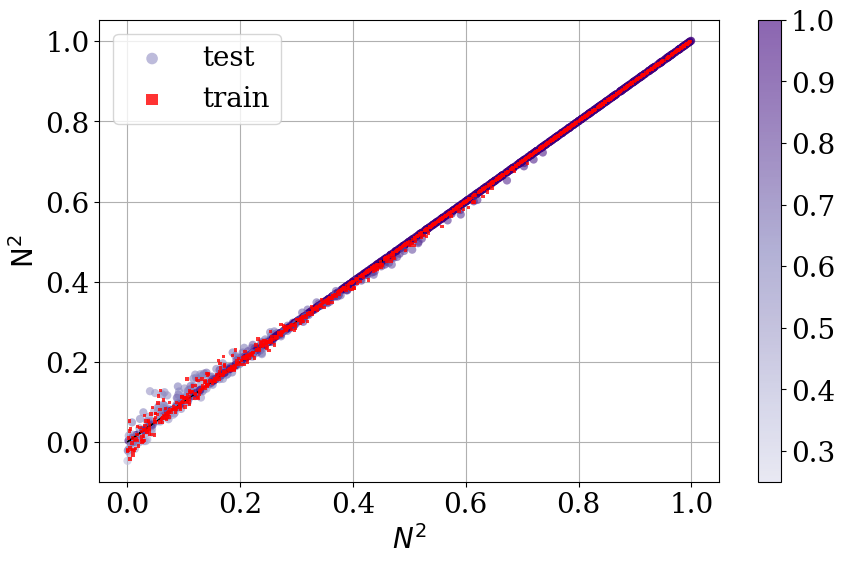

In [17]:
dms=(dms_train, dms_test)
labels=(labels_train, labels_test)
save_plot='qubits_f38_mixedTrain_negSq_1000.pdf'
plot_prediction_func_tt(pars, func=func_E38, dms=dms, labels=labels, results_only=False, save_plot=save_plot, titleMSEVar=False)

In [18]:
# If the patterns in combs_AB have structure, you can further optimize:
def func_E_structured(pars, dm):
    """
    Optimized version that exploits structure in combs_AB.
    This is highly dependent on your specific combs_AB patterns.
    """
    # Group combinations by (xi, yi, zi) pattern to avoid duplicate computations
    from collections import defaultdict
    
    # Create mapping from (xi, yi, zi) to list of indices
    pattern_to_indices = defaultdict(list)
    
    for idx, (comb_A, comb_B) in enumerate(combs_AB):
        for comb in [comb_A, comb_B]:
            pattern_to_indices[tuple(comb)].append(idx)
    
    # Precompute values for each unique pattern
    PT1 = partial_trace(dm, subsystem=1)
    PT2 = partial_trace(dm, subsystem=0)
    
    pattern_values = {}
    for (xi, yi, zi), indices in pattern_to_indices.items():
        if xi == 0:
            dm_pow = np.eye(dm.shape[0])
        else:
            dm_pow = np.linalg.matrix_power(dm, xi)
        
        if yi == 0 and zi == 0:
            kron_mat = np.eye(dm.shape[0])
        else:
            pt1_pow = np.eye(PT1.shape[0]) if yi == 0 else np.linalg.matrix_power(PT1, yi)
            pt2_pow = np.eye(PT2.shape[0]) if zi == 0 else np.linalg.matrix_power(PT2, zi)
            kron_mat = np.kron(pt1_pow, pt2_pow)
        
        pattern_values[(xi, yi, zi)] = np.trace(dm_pow @ kron_mat).real
    
    # Now compute the sum
    total = 0
    for par, (comb_A, comb_B) in zip(pars[:len(combs_AB)], combs_AB):
        term_A = pattern_values[tuple(comb_A)]
        term_B = pattern_values[tuple(comb_B)]
        total += par * term_A * term_B
    
    # Add remaining terms
    n = len(combs_AB)
    if len(pars) > n:
        total += pars[-1] * fn_rho3(dm)
    if len(pars) > n + 1:
        total += pars[-2] * fn_rho5_a(dm)
    if len(pars) > n + 2:
        total += pars[-3] * fn_rho5_b(dm)
    
    return total
def train_E38(dms, labels):
    method = 'BFGS'
    n_pars = 38
    #print(f"number of parameters in combs = %i"%n_pars)
    fvals = []  # This will store the history for the callback
    fun_vals_history = []  # <-- NEW: This will persist across all calls to `fun`
    time_zero=time()
    def fun(x):
        pred_vals = []
        start_time = time()
        for dm in dms:
            pred_vals.append(func_E_structured(x, dm))
        finish_time=time()
        #print("Overall spent time for dms_train calculations: %.3f"%(finish_time-start_time), end="\r")
        

        f = least_squares_cost(labels, pred_vals)
        fun_vals_history.append(f)  # <-- NEW
        return f
    
    def callback(x):
        if fun_vals_history:  
            current_fval = fun_vals_history[-1]
            fvals.append(current_fval)
            print("Iteration: %d | Function value: %.6f | Time passed %.3f" % (len(fvals), current_fval, time()-time_zero))#, end="\r")
        return None
   
    x0 = [random.uniform(-2, 2) for i in range(n_pars)]
        #print(len(x0), n_pars, n_pars+2)
    #print(f"number of parameters in x0 = %i"%len(x0))
    optimization_result = minimize(fun=fun, x0=x0, method=method, callback=callback)
    params = optimization_result.x

    # Return the history of function values recorded by the callback
    return fvals, params, optimization_result

In [19]:
fun_valsF_p3_mixed, parsF_p3_mixed, optimization_resultF_p3_mixed=train_E38(dms_train_easy_np, labels_train_easy)

Iteration: 1 | Function value: 1074831.094931 | Time passed 65.006
Iteration: 2 | Function value: 1068921.418674 | Time passed 132.852
Iteration: 3 | Function value: 1066386.449471 | Time passed 166.019
Iteration: 4 | Function value: 675758.086293 | Time passed 300.913
Iteration: 5 | Function value: 522689.670399 | Time passed 369.263
Iteration: 6 | Function value: 259218.709661 | Time passed 402.764
Iteration: 7 | Function value: 0.039830 | Time passed 435.225
Iteration: 8 | Function value: 0.023200 | Time passed 466.654
Iteration: 9 | Function value: 0.022800 | Time passed 499.592


MSE_train=0.00002280, MSE_test=0.20440076


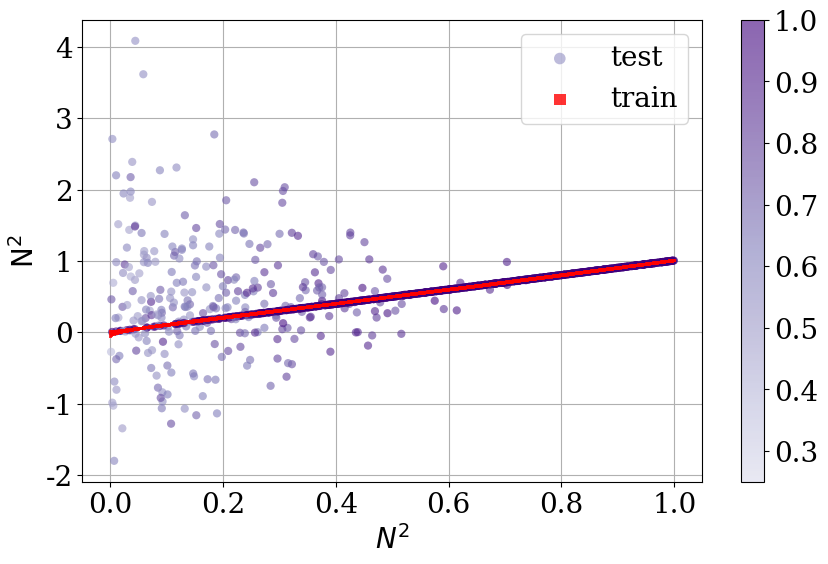

In [20]:
dms=(dms_train_easy_np, dms_test)
labels=(labels_train_easy, labels_test)
save_plot='qubits_f38_easyTrain_negSq_1000.pdf'
plot_prediction_func_tt(parsF_p3_mixed, func=func_E_structured, dms=dms, labels=labels, results_only=False, save_plot=save_plot, titleMSEVar=False)

### Training 10 functions:

In [21]:
fn10p_s=[fn_rho1, fn_rho2, fn_rho3,  fn_rho4_ab, fn_rho5_ab, fn_rho6_ab, fn_rho7, fn_rho8, fn_rho9_ab, fn_rho10]

In [22]:
pars_10p=train_func(fn10p_s, dms_train, labels_train)

In [23]:
fn10p_s

[<function __main__.fn_rho1(dm)>,
 <function __main__.fn_rho2(dm)>,
 <function __main__.fn_rho3(dm)>,
 <function __main__.fn_rho4_ab(dm)>,
 <function __main__.fn_rho5_ab(dm)>,
 <function __main__.fn_rho6_ab(dm)>,
 <function __main__.fn_rho7(dm)>,
 <function __main__.fn_rho8(dm)>,
 <function __main__.fn_rho9_ab(dm)>,
 <function __main__.fn_rho10(dm)>]

MSE_train=0.00001268, MSE_test=0.00001129


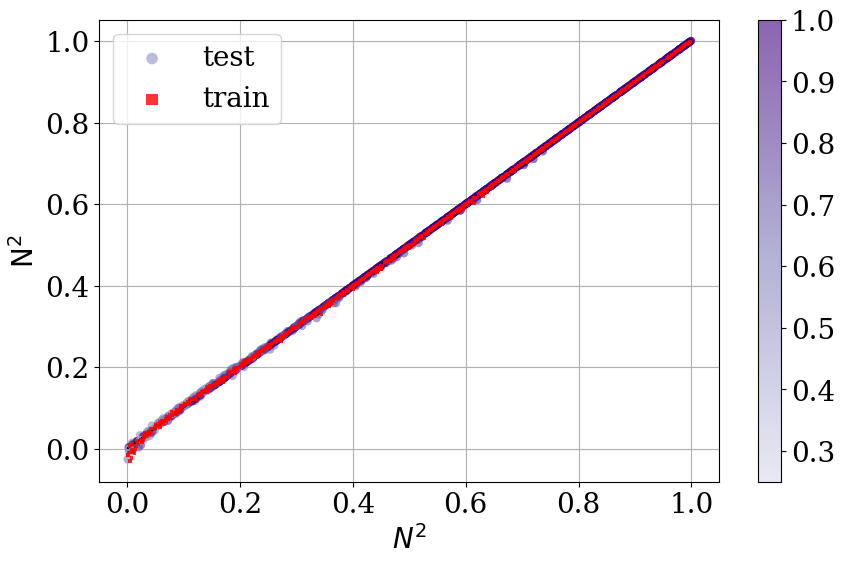

In [24]:
dms=(dms_train, dms_test)
labels=(labels_train, labels_test)
save_plot='qubits_f10_mixedTrain_negSq_1000.pdf'
plot_prediction_func_tt(pars_10p, func=fun_reg, dms=dms, labels=labels,func_args=(fn10p_s,), results_only=False, save_plot=save_plot, titleMSEVar=False)

In [25]:
pars_10p_easy=train_func(fn10p_s, dms_train_easy_np, labels_train_easy)

MSE_train=0.00002280, MSE_test=0.00026679


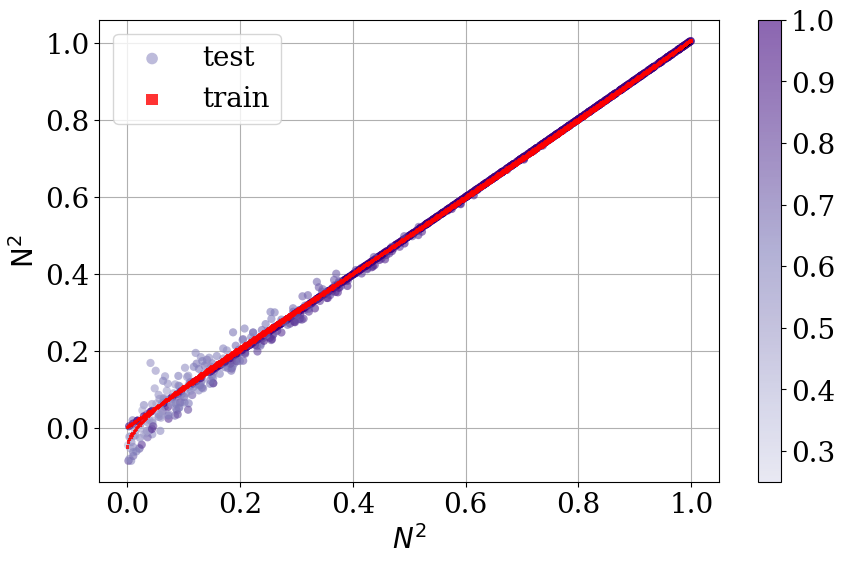

In [26]:
dms=(dms_train_easy_np, dms_test)
labels=(labels_train_easy, labels_test)
save_plot='qubits_f10_easyTrain_negSq_1000.pdf'
plot_prediction_func_tt(pars_10p_easy, func=fun_reg, dms=dms, labels=labels,func_args=(fn10p_s,), results_only=False, save_plot=save_plot, titleMSEVar=False)

### PT-moment based model

In [27]:
def pt_moment(dm, mom=3):
    def partial_transpose(A, n, m):
        A_c = array(A)
        Bt = A[:n, m:].copy()
        Ct = A[n:, :m].copy()
        A_c[:n, m:] = Ct
        A_c[n:, :m] = Bt
        return A_c
    dm_ptrans = partial_transpose(dm, int(len(dm)/2), int(len(dm)/2))
    #lambda_min = eigh(dm_ptrans)[0][0]
    #return 2*abs(min(0, lambda_min))
    id=np.eye(len(dm_ptrans))
    for i in range(mom):
        id=id@dm_ptrans
    return np.trace(id).real
pt_moment(dms_test[89],3), np.trace(dms_test[89]@dms_test[89]).real
def pt_moment3(dm):
    return pt_moment(dm, mom=3)
def pt_moment4(dm):
    return pt_moment(dm, mom=4)

In [28]:
fn_PT=[fn_rho10, fn_rho6_ab, fn_rho2,  pt_moment3, pt_moment4]

In [29]:
pars_PT=train_func(fn_PT, dms_train, labels_train)

MSE_train=0.00006943, MSE_test=0.00006858


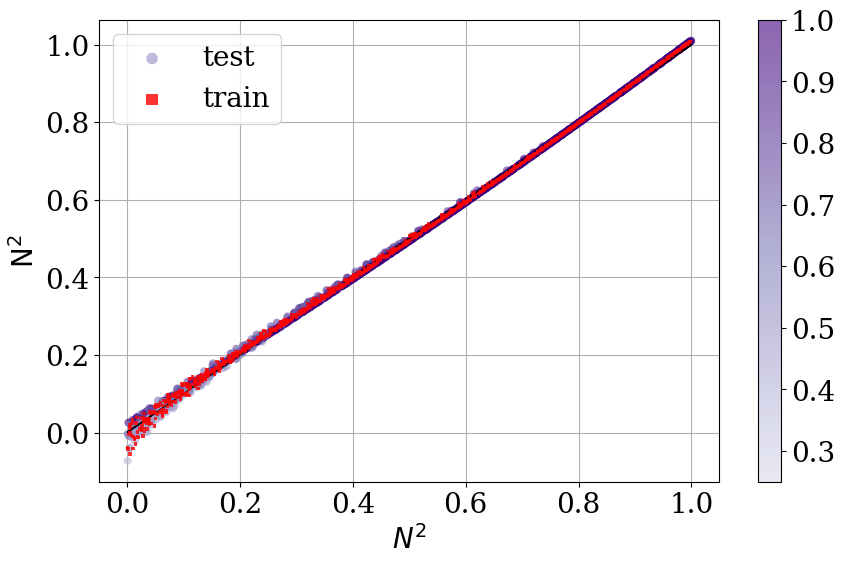

In [30]:
dms=(dms_train, dms_test)
labels=(labels_train, labels_test)
save_plot='qubits_custom_mixedTrain_negSq_1000.pdf'
plot_prediction_func_tt(pars_PT, func=fun_reg, dms=dms, labels=labels,func_args=(fn_PT,), results_only=False, save_plot=save_plot, titleMSEVar=False)

In [31]:
pars_PT_easy=train_func(fn_PT, dms_train_easy_np, labels_train_easy)

MSE_train=0.00001169, MSE_test=0.00144112


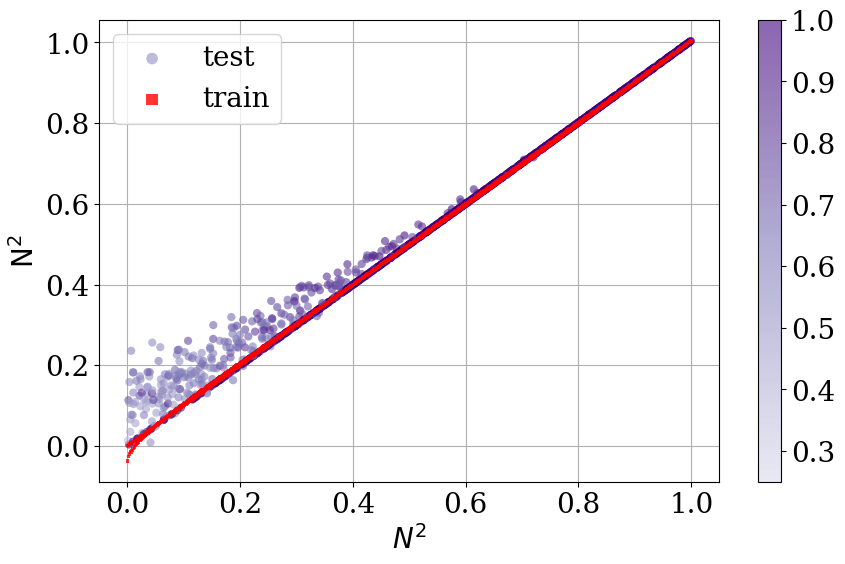

In [32]:
dms=(dms_train_easy_np, dms_test)
labels=(labels_train_easy, labels_test)
save_plot='qubits_custom_easyTrain_negSq_1000.pdf'
plot_prediction_func_tt(pars_PT_easy, func=fun_reg, dms=dms, labels=labels,func_args=(fn_PT,), results_only=False, save_plot=save_plot, titleMSEVar=False)

### Five-selected model

In [33]:
fn_selected=[fn_rho1, fn_rho5_ab, fn_rho9_ab, fn_rho6_ab, fn_rho2]

In [34]:
pars_fn_selected=train_func(fn_selected, dms_train, labels_train)

MSE_train=0.00011155, MSE_test=0.00012099


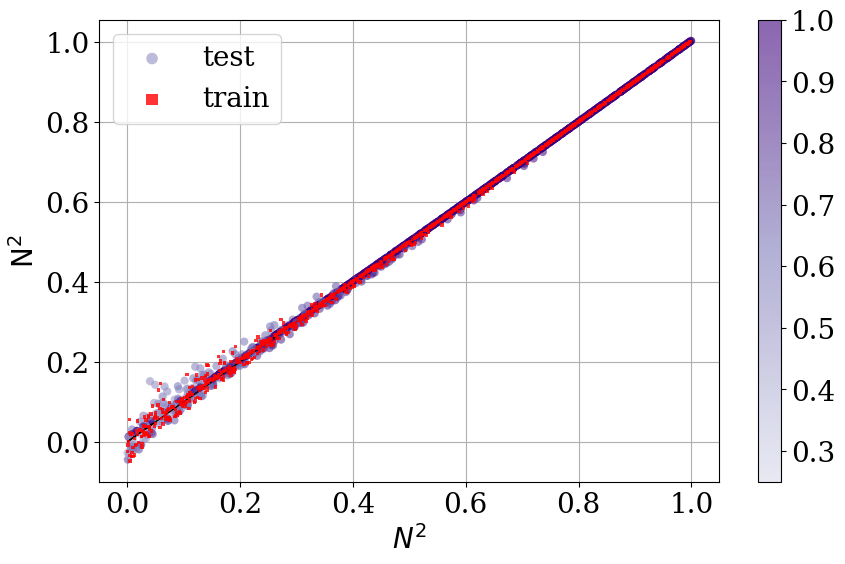

In [35]:
dms=(dms_train, dms_test)
labels=(labels_train, labels_test)
save_plot='qubits_fiveSelected_mixedTrain_negSq_1000.pdf'
plot_prediction_func_tt(pars_fn_selected, func=fun_reg, dms=dms, labels=labels,func_args=(fn_selected,), results_only=False, save_plot=save_plot, titleMSEVar=False)

In [36]:
pars_fn_selected_easy=train_func(fn_selected, dms_train_easy_np, labels_train_easy)

MSE_train=0.00002280, MSE_test=0.00015962


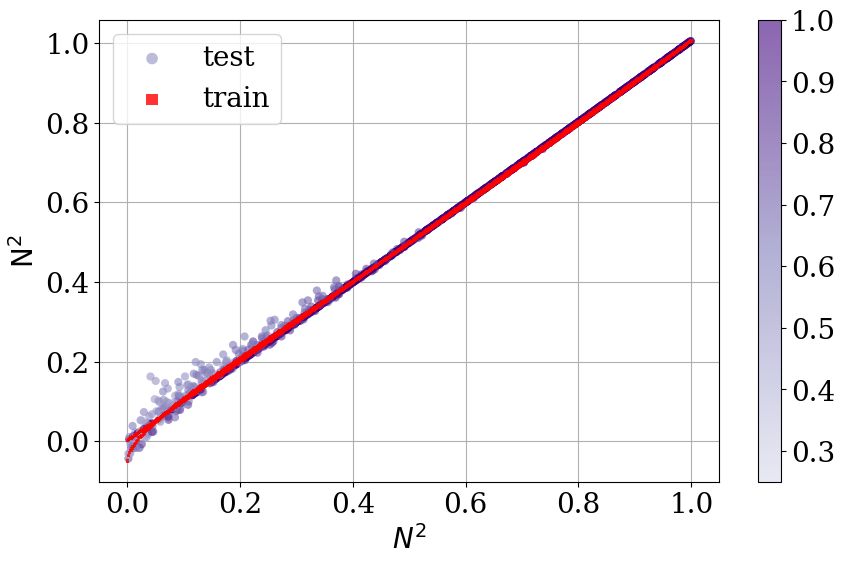

In [37]:
dms=(dms_train_easy_np, dms_test)
labels=(labels_train_easy, labels_test)
save_plot='qubits_fiveSelected_easyTrain_negSq_1000.pdf'
plot_prediction_func_tt(pars_fn_selected_easy, func=fun_reg, dms=dms, labels=labels,func_args=(fn_selected,), results_only=False, save_plot=save_plot, titleMSEVar=False)

### Reducing the function counts

In [38]:
def train_func2(fn_s, dms, labels):
    # Build the feature matrix the same way func_E would evaluate it
    X = np.array([[fn(dm) for fn in fn_s] for dm in dms])
    y = np.array(labels)

    regressor = LinearRegression(fit_intercept=True)
    regressor.fit(X, y)

    params = regressor.coef_

    # Mirror the original return signature
    y_pred = X @ params + regressor.intercept_
    final_cost = least_squares_cost(labels, y_pred)
    fvals = [final_cost]   # No iterations — solved in one step

    return params
def return_mse(dms, labels, fn_s, n_times=2):
    
    dms_train, dms_test = dms
    labels_train, labels_test = labels
    total_mse_tests = []
    for i in range(n_times):
        
        #fvals_fs, params_fs, optimization_result_fs=train_func(dms_train, labels_train, fn_s=fn_s)
        params_fs=train_func(fn_s, dms_train, labels_train)
        #fun_reg(pars,  dm, fn_s)
        preds_test = [fun_reg(pars=params_fs, dm=dm, fn_s=fn_s) for dm in dms_test]
        #preds_test = [func_E(pars=params_fs, dm=dm, fn_s=fn_s) for dm in dms_test]

        total_mse_test = sum([(e1 - e2)**2 for e1, e2 in zip(preds_test, labels_test)]) / len(labels_test)
        total_mse_tests.append(total_mse_test)
    return mean(total_mse_tests)
dms=(dms_train, dms_test)
labels=(labels_train, labels_test)
return_mse(dms, labels, fn_s=fn10p_s)

1.1289745261825905e-05

In [39]:
fn_r = fn10p_s.copy()
minums = []
pops = []

for i in range(9):
    mse_s = []
    popped = []
    
    for j in range(len(fn_r)):
        fn_r2 = fn_r.copy()
        popped.append(fn_r2.pop(j))
        mse = return_mse(dms, labels, fn_r2)
        mse_s.append(mse)
        print("(i, j) =", i, j, end="\r")
    
    # CORRECTED LINE - use mse_s.index() method
    min_index = mse_s.index(min(mse_s))
    a_pop=fn_r.pop(min_index)
    pops.append(a_pop)
    a_min=min(mse_s)
    minums.append(a_min)
    print(a_pop, a_min)

<function fn_rho8 at 0x000002B7ECC97100> 1.422137137073996e-05
<function fn_rho9_ab at 0x000002B7ECC972E0> 2.1598964475111577e-05
<function fn_rho10 at 0x000002B7ECC97380> 2.4947327809138948e-05
<function fn_rho6_ab at 0x000002B7ECC96FC0> 3.0521521408690016e-05
<function fn_rho5_ab at 0x000002B7ECC96DE0> 0.0001503472986032114
<function fn_rho7 at 0x000002B7ECC97060> 0.00016595690241498593
<function fn_rho3 at 0x000002B7ECC95620> 0.00019548359132121875
<function fn_rho2 at 0x000002B7ECC95BC0> 0.002934768010201311
<function fn_rho4_ab at 0x000002B7ECC96C00> 0.04811198716914791


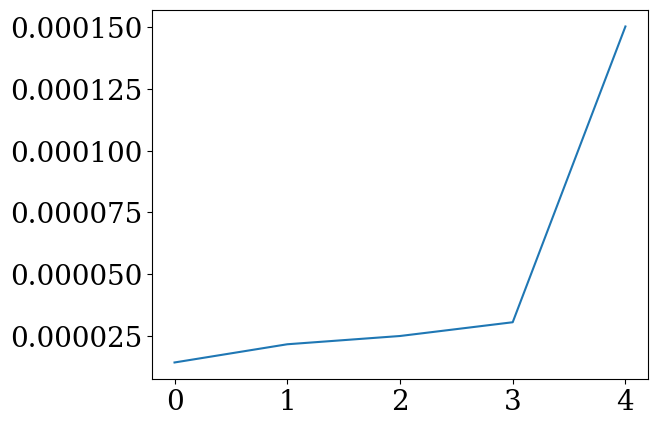

In [40]:
plt.plot(minums[:-4])

In [41]:
fn_r = fn10p_s.copy()
minums_easy = []
pops_easy = []
dms=(dms_train_easy_np, dms_test)
labels=(labels_train_easy, labels_test)
return_mse(dms, labels, fn_s=fn10p_s)
for i in range(9):
    mse_s = []
    popped = []
    for j in range(len(fn_r)):
        fn_r2 = fn_r.copy()
        popped.append(fn_r2.pop(j))
        mse = return_mse(dms, labels, fn_r2)
        mse_s.append(mse)
        print("(i, j) =", i, j, end="\r")
    
    # CORRECTED LINE - use mse_s.index() method
    min_index = mse_s.index(min(mse_s))
    a_pop=fn_r.pop(min_index)
    pops_easy.append(a_pop)
    a_min=min(mse_s)
    minums_easy.append(a_min)
    print(i+1, " Removed function: ",a_pop," MSE:", a_min)

1  Removed function:  <function fn_rho10 at 0x000002B7ECC97380>  MSE: 0.00018769205451080046
2  Removed function:  <function fn_rho3 at 0x000002B7ECC95620>  MSE: 0.00016241301607614378
3  Removed function:  <function fn_rho7 at 0x000002B7ECC97060>  MSE: 0.00016102007265750935
4  Removed function:  <function fn_rho4_ab at 0x000002B7ECC96C00>  MSE: 0.00015994602222082216
5  Removed function:  <function fn_rho8 at 0x000002B7ECC97100>  MSE: 0.00015962435691786923
6  Removed function:  <function fn_rho2 at 0x000002B7ECC95BC0>  MSE: 0.00022721770230528973
7  Removed function:  <function fn_rho6_ab at 0x000002B7ECC96FC0>  MSE: 0.00034839648224825473
8  Removed function:  <function fn_rho9_ab at 0x000002B7ECC972E0>  MSE: 0.00037918359312976373
9  Removed function:  <function fn_rho5_ab at 0x000002B7ECC96DE0>  MSE: 0.04833963812494785


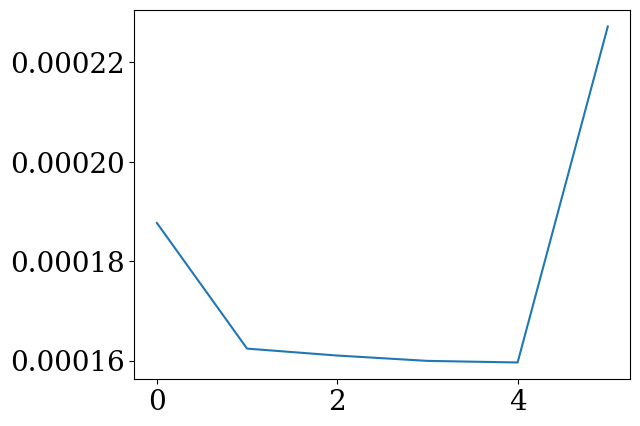

In [42]:
plt.plot(minums_easy[:-3])

In [43]:
fn_selected

[<function __main__.fn_rho1(dm)>,
 <function __main__.fn_rho5_ab(dm)>,
 <function __main__.fn_rho9_ab(dm)>,
 <function __main__.fn_rho6_ab(dm)>,
 <function __main__.fn_rho2(dm)>]

MSE_train=0.00002280, MSE_test=0.00015962


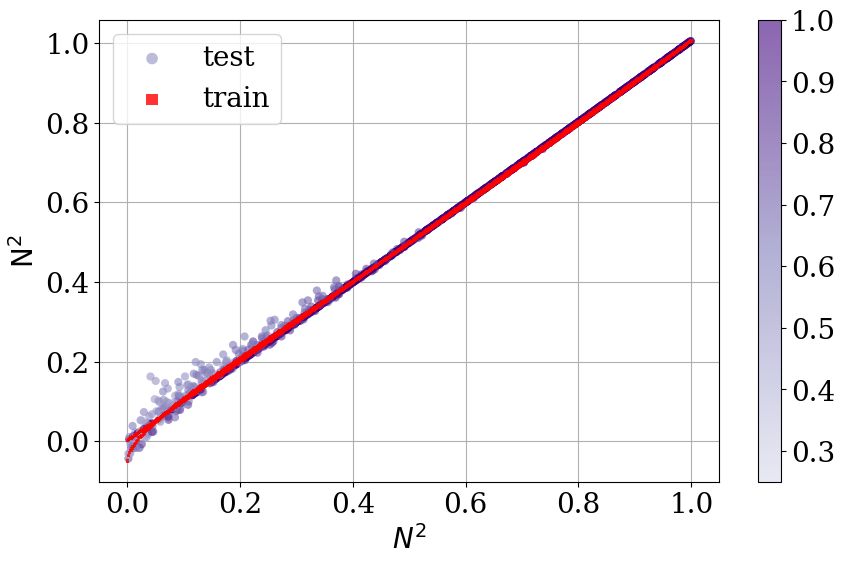

In [44]:
pars_fn_selected_5_easy=train_func(fn_selected, dms_train_easy_np, labels_train_easy)
dms=(dms_train_easy_np, dms_test)
labels=(labels_train_easy, labels_test)
plot_prediction_func_tt(pars_fn_selected_5_easy, func=fun_reg, dms=dms, labels=labels,func_args=(fn_selected,), results_only=False, save_plot=None, titleMSEVar=False)

### Extra: with optimization

In [45]:
def func_E(pars, dm, fn_s=fn10p_s):
    sums=0
    for par, fn in zip(pars, fn_s):
        sums+=par*fn(dm)        
    return sums
def train_E_opt(dms, labels, fn_s):
    method = 'BFGS'
    n_pars = len(fn_s)
    #print(f"number of parameters in combs = %i"%n_pars)
    fvals = []  # This will store the history for the callback
    fun_vals_history = []  # <-- NEW: This will persist across all calls to `fun`
    time_zero=time()
    def fun(x):
        pred_vals = []
        start_time = time()
        for dm in dms:
            pred_vals.append(func_E(x, dm, fn_s))
        finish_time=time()
        #print("Overall spent time for dms_train calculations: %.3f"%(finish_time-start_time), end="\r")
        

        f = least_squares_cost(labels, pred_vals)
        fun_vals_history.append(f)  # <-- NEW
        return f
    
    def callback(x):
        if fun_vals_history:  
            current_fval = fun_vals_history[-1]
            fvals.append(current_fval)
            #print("Iteration: %d | Function value: %.6f | Time passed %.3f" % (len(fvals), current_fval, time()-time_zero))#, end="\r")
        return None
   
    x0 = [random.uniform(-2, 2) for i in range(n_pars)]
        #print(len(x0), n_pars, n_pars+2)
    #print(f"number of parameters in x0 = %i"%len(x0))
    optimization_result = minimize(fun=fun, x0=x0, method=method, callback=callback)
    params = optimization_result.x

    # Return the history of function values recorded by the callback
    return fvals, params, optimization_result

In [46]:
def return_mse_opt(dms, labels, fn_s, n_times=6):
    
    dms_train, dms_test = dms
    labels_train, labels_test = labels
    total_mse_tests = []
    for i in range(n_times):
        
        #fvals_fs, params_fs, optimization_result_fs=train_func(dms_train, labels_train, fn_s=fn_s)
        fvals, params_fs, optimization_result = train_E_opt(dms_train, labels_train, fn_s)
        #fun_reg(pars,  dm, fn_s)
        preds_test = [fun_reg(pars=params_fs, dm=dm, fn_s=fn_s) for dm in dms_test]
        #preds_test = [func_E(pars=params_fs, dm=dm, fn_s=fn_s) for dm in dms_test]

        total_mse_test = sum([(e1 - e2)**2 for e1, e2 in zip(preds_test, labels_test)]) / len(labels_test)

        total_mse_tests.append(total_mse_test)
    return mean(total_mse_tests)
# dms=(dms_train_easy_np, dms_test)
# labels=(labels_train_easy, labels_test)
# return_mse_opt(dms, labels, fn_s=fn10p_s)

In [47]:
# return_mse(dms, labels, fn_s=fn10p_s)

In [48]:
fn_r = fn10p_s.copy()
minums_easy_opt = []
pops_easy_opt = []
dms=(dms_train_easy_np, dms_test)
labels=(labels_train_easy, labels_test)
for i in range(9):
    mse_s = []
    popped = []
    
    for j in range(len(fn_r)):
        fn_r2 = fn_r.copy()
        popped.append(fn_r2.pop(j))
        mse = return_mse_opt(dms, labels, fn_r2)
        mse_s.append(mse)
        print("(i, j) =", i, j, end="\r")
    
    # CORRECTED LINE - use mse_s.index() method
    min_index = mse_s.index(min(mse_s))
    a_pop=fn_r.pop(min_index)
    pops_easy_opt.append(a_pop)
    a_min=mse_s[min_index]
    minums_easy_opt.append(a_min)
    print(a_pop, a_min)

<function fn_rho10 at 0x000002B7ECC97380> 0.00024333342697313763
<function fn_rho3 at 0x000002B7ECC95620> 0.0002848890285192237
<function fn_rho7 at 0x000002B7ECC97060> 0.00021050178143349236
<function fn_rho4_ab at 0x000002B7ECC96C00> 0.00016096770164896918
<function fn_rho8 at 0x000002B7ECC97100> 0.00015962409037606747
<function fn_rho2 at 0x000002B7ECC95BC0> 0.00022721777185327483
<function fn_rho6_ab at 0x000002B7ECC96FC0> 0.0003483963320829557
<function fn_rho9_ab at 0x000002B7ECC972E0> 0.00037918348606215684
<function fn_rho5_ab at 0x000002B7ECC96DE0> 0.04833963803712426


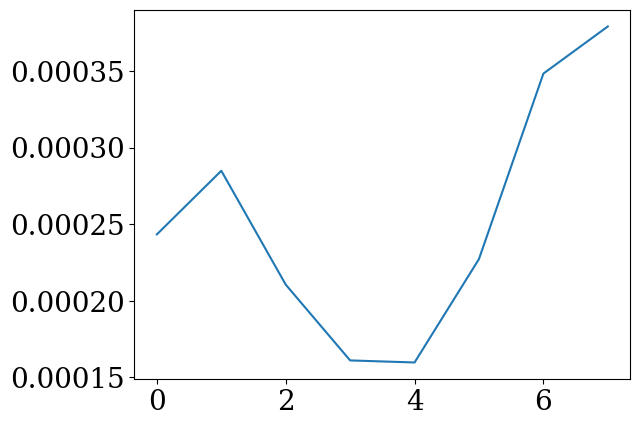

In [49]:
plt.plot(minums_easy_opt[:-1])

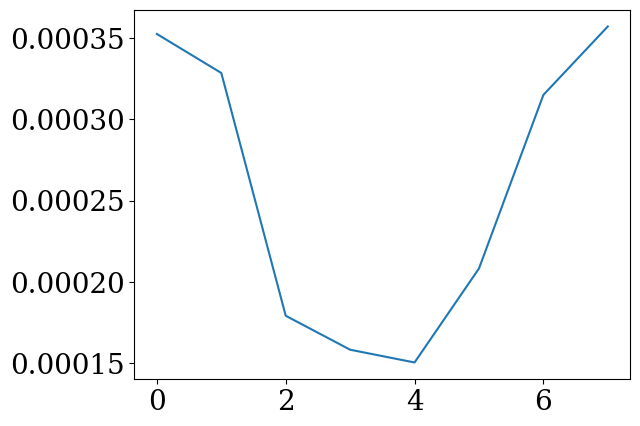

In [69]:
plt.plot(minums_easy_opt[:-1])

In [172]:
fn_r = fn10p_s.copy()
minums_easy_opt = []
pops_easy_opt = []
dms=(dms_train_easy_np, dms_test)
labels=(labels_train_easy, labels_test)
for i in range(9):
    mse_s = []
    popped = []
    
    for j in range(len(fn_r)):
        fn_r2 = fn_r.copy()
        popped.append(fn_r2.pop(j))
        mse = return_mse_opt(dms, labels, fn_r2)
        mse_s.append(mse)
        print("(i, j) =", i, j, end="\r")
    
    # CORRECTED LINE - use mse_s.index() method
    min_index = mse_s.index(min(mse_s))
    a_pop=fn_r.pop(min_index)
    pops_easy_opt.append(a_pop)
    a_min=mse_s[min_index]
    minums_easy_opt.append(a_min)
    print(a_pop, a_min)

<function fn_rho6_ab at 0x00000253FD866C00> 0.0002720982293464692
<function fn_rho10 at 0x00000253FD866340> 0.0002578256444880494
<function fn_rho5_ab at 0x00000253FD8649A0> 0.0002745426815565207
<function fn_rho2 at 0x00000253FEC91EE0> 0.00020135228983356328
<function fn_rho4_ab at 0x00000253FD88C9A0> 0.0001690701042078945
<function fn_rho8 at 0x00000253FD866B60> 0.00015437149990851385
<function fn_rho9_ab at 0x00000253FD864D60> 0.0004440192934630258
<function fn_rho7 at 0x00000253FD8668E0> 0.0017753595981809327
<function fn_rho3 at 0x00000253FD88F600> 0.04583918793046011


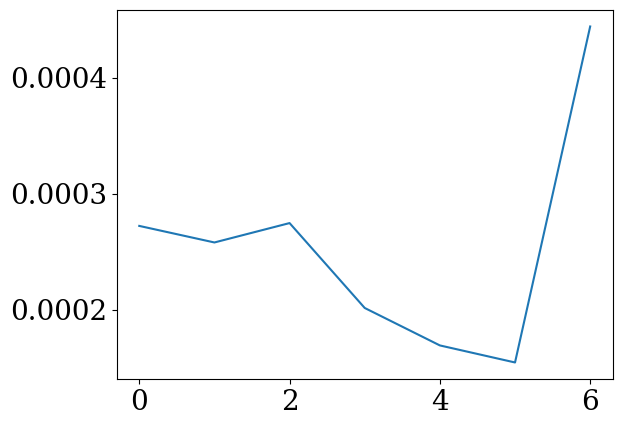

In [61]:
dd=[0.0002720982293464692, 0.0002578256444880494, 0.0002745426815565207, 0.00020135228983356328,  0.0001690701042078945, 0.00015437149990851385, 0.0004440192934630258]
plt.plot(dd)